In [1]:
# Install (if needed)
!pip install torch

In [2]:
# Import
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


In [3]:
# Dummy dataset (random data)
torch.manual_seed(0)
seq_len = 10
d_model = 32
num_samples = 500

X = torch.randn(num_samples, seq_len, d_model)
y = torch.randn(num_samples, seq_len, d_model)

In [4]:
# Simple Transformer Encoder Block
class SimpleTransformer(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, num_heads, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model*2),
            nn.ReLU(),
            nn.Linear(d_model*2, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        attn_output, _ = self.attn(x, x, x)
        x = self.norm1(x + attn_output)

        ffn_output = self.ffn(x)
        x = self.norm2(x + ffn_output)
        return x

In [5]:
# Simple Transformer Encoder Block
class SimpleTransformer(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, num_heads, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model*2),
            nn.ReLU(),
            nn.Linear(d_model*2, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        attn_output, _ = self.attn(x, x, x)
        x = self.norm1(x + attn_output)

        ffn_output = self.ffn(x)
        x = self.norm2(x + ffn_output)
        return x

In [6]:
# Training function
def train_model(num_heads):
    model = SimpleTransformer(d_model, num_heads)
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    loss_fn = nn.MSELoss()

    losses = []
    print(f"\nTraining with {num_heads} heads")

    for epoch in range(20):
        optimizer.zero_grad()
        output = model(X)
        loss = loss_fn(output, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        # Print loss each epoch
        print(f"Heads: {num_heads} | Epoch: {epoch+1} | Loss: {loss.item():.4f}")

    return losses

In [8]:
# Run Experiment

head_list = [1, 2, 4, 8]
results = {}

for h in head_list:
    results[h] = train_model(h)


Training with 1 heads
Heads: 1 | Epoch: 1 | Loss: 1.9964
Heads: 1 | Epoch: 2 | Loss: 1.9607
Heads: 1 | Epoch: 3 | Loss: 1.9252
Heads: 1 | Epoch: 4 | Loss: 1.8880
Heads: 1 | Epoch: 5 | Loss: 1.8489
Heads: 1 | Epoch: 6 | Loss: 1.8083
Heads: 1 | Epoch: 7 | Loss: 1.7674
Heads: 1 | Epoch: 8 | Loss: 1.7273
Heads: 1 | Epoch: 9 | Loss: 1.6887
Heads: 1 | Epoch: 10 | Loss: 1.6519
Heads: 1 | Epoch: 11 | Loss: 1.6167
Heads: 1 | Epoch: 12 | Loss: 1.5828
Heads: 1 | Epoch: 13 | Loss: 1.5502
Heads: 1 | Epoch: 14 | Loss: 1.5185
Heads: 1 | Epoch: 15 | Loss: 1.4879
Heads: 1 | Epoch: 16 | Loss: 1.4582
Heads: 1 | Epoch: 17 | Loss: 1.4296
Heads: 1 | Epoch: 18 | Loss: 1.4021
Heads: 1 | Epoch: 19 | Loss: 1.3758
Heads: 1 | Epoch: 20 | Loss: 1.3506

Training with 2 heads
Heads: 2 | Epoch: 1 | Loss: 1.9946
Heads: 2 | Epoch: 2 | Loss: 1.9581
Heads: 2 | Epoch: 3 | Loss: 1.9213
Heads: 2 | Epoch: 4 | Loss: 1.8828
Heads: 2 | Epoch: 5 | Loss: 1.8427
Heads: 2 | Epoch: 6 | Loss: 1.8016
Heads: 2 | Epoch: 7 | Loss: 1.760

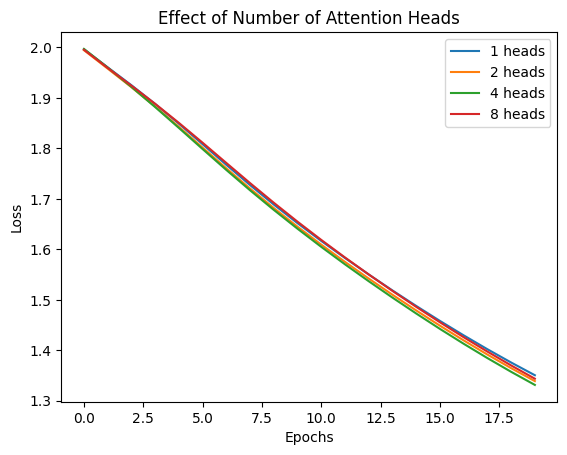

In [9]:
# Plot Results

plt.figure()

for h in head_list:
    plt.plot(results[h], label=f"{h} heads")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Effect of Number of Attention Heads")
plt.legend()
plt.show()

In [10]:
# Final Comparison

print("\n Final Loss Comparison")
for h in head_list:
    print(f"{h} heads → Final Loss: {results[h][-1]:.4f}")


 Final Loss Comparison
1 heads → Final Loss: 1.3506
2 heads → Final Loss: 1.3389
4 heads → Final Loss: 1.3314
8 heads → Final Loss: 1.3437
